In [1]:
# ============================================================================
# RETAIL SALES ANALYTICS — SUPERMART GROCERY
# ============================================================================
# Author  : Roshani Dadaji Ahire
# Dataset : Supermart Grocery Sales — Retail Analytics (9,994 records)
#
# DATASET NOTE:
# This is a synthetic practice dataset. All categories show fixed ~25% margins,
# and only 50 unique customers placed 9,993 orders — both are artificial patterns
# that wouldn't appear in real grocery retail. The analysis demonstrates
# real analytics techniques applied honestly to this data.
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from dateutil import parser
import warnings

from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

import os
os.makedirs('images', exist_ok=True)


In [ ]:
# ============================================================================
# SECTION 1 — LOAD DATA
# ============================================================================

data = pd.read_csv('/content/Supermart Grocery Sales - Retail Analytics Dataset.csv')
print("=" * 70)
print("SUPERMART GROCERY — RETAIL SALES ANALYTICS")
print("=" * 70)
print(f"\nRows: {data.shape[0]:,}   Columns: {data.shape[1]}")
print(f"\nColumns: {data.columns.tolist()}")
print(f"\nData types:\n{data.dtypes}")
print(f"\nMissing values:\n{data.isnull().sum()}")

SUPERMART GROCERY — RETAIL SALES ANALYTICS

Rows: 9,994   Columns: 11

Columns: ['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City', 'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State']

Data types:
Order ID          object
Customer Name     object
Category          object
Sub Category      object
City              object
Order Date        object
Region            object
Sales              int64
Discount         float64
Profit           float64
State             object
dtype: object

Missing values:
Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64


In [ ]:
# ============================================================================
# SECTION 2 — DATA CLEANING
# ============================================================================

# ── 2a  Region: remove the single 'North' record (data error) ───────────────
print(f"\nRegion distribution:\n{data['Region'].value_counts()}")

data = data[data['Region'] != 'North'].copy()
print(f"\nAfter removing lone 'North' record: {data.shape[0]:,} rows remain")



Region distribution:
Region
West       3203
East       2848
Central    2323
South      1619
North         1
Name: count, dtype: int64

After removing lone 'North' record: 9,993 rows remain


In [ ]:
# ── 2b  State: only one unique value (Tamil Nadu) — not useful as a feature ─
print(f"\nUnique states: {data['State'].nunique()} — {data['State'].unique()}")
data.drop(columns=['State'], inplace=True)

# ── 2c  Parse Order Date — handle mixed formats ──────────────────────────────
def clean_date(x):
    try:
        return parser.parse(str(x), dayfirst=True)
    except Exception:
        return pd.NaT

data['Order Date'] = data['Order Date'].apply(clean_date)
print(f"\nInvalid dates: {data['Order Date'].isna().sum()}")
print(f"Date range: {data['Order Date'].min().date()} to {data['Order Date'].max().date()}")

# ── 2d  Extract date features ────────────────────────────────────────────────
data['Year']  = data['Order Date'].dt.year
data['Month'] = data['Order Date'].dt.month

# ── 2e  Business rule validation ─────────────────────────────────────────────
checks = {
    "Sales ≤ 0"         : (data['Sales'] <= 0).sum(),
    "Discount out of range": ((data['Discount'] < 0) | (data['Discount'] > 1)).sum(),
    "Profit missing"    : data['Profit'].isna().sum(),
}
print("\nValidation checks:")
for k, v in checks.items():
    print(f"  {k}: {v}")

# ── 2f  Derived metric ───────────────────────────────────────────────────────
data['Profit_Margin'] = data['Profit'] / data['Sales']

print(f"\nCleaned dataset: {data.shape[0]:,} rows, {data.shape[1]} columns")



Unique states: 1 — ['Tamil Nadu']

Invalid dates: 0
Date range: 2015-01-02 to 2018-12-30

Validation checks:
  Sales ≤ 0: 0
  Discount out of range: 0
  Profit missing: 0

Cleaned dataset: 9,993 rows, 13 columns



DATA OVERVIEW

Summary statistics:
          Sales  Discount    Profit  Profit_Margin
count  9993.000  9993.000  9993.000       9993.000
mean   1496.620     0.227   374.934          0.250
std     577.583     0.075   239.945          0.119
min     500.000     0.100    25.250          0.050
25%    1000.000     0.160   180.000          0.150
50%    1498.000     0.230   320.760          0.250
75%    1995.000     0.290   525.690          0.350
max    2500.000     0.350  1120.950          0.450

Categories (7): ['Beverages' 'Food Grains' 'Fruits & Veggies' 'Bakery' 'Snacks'
 'Eggs, Meat & Fish' 'Oil & Masala']
Sub-categories: 23
Cities: 24
Regions: ['South' 'West' 'Central' 'East']
Unique customers: 50
Orders per customer (avg): 200


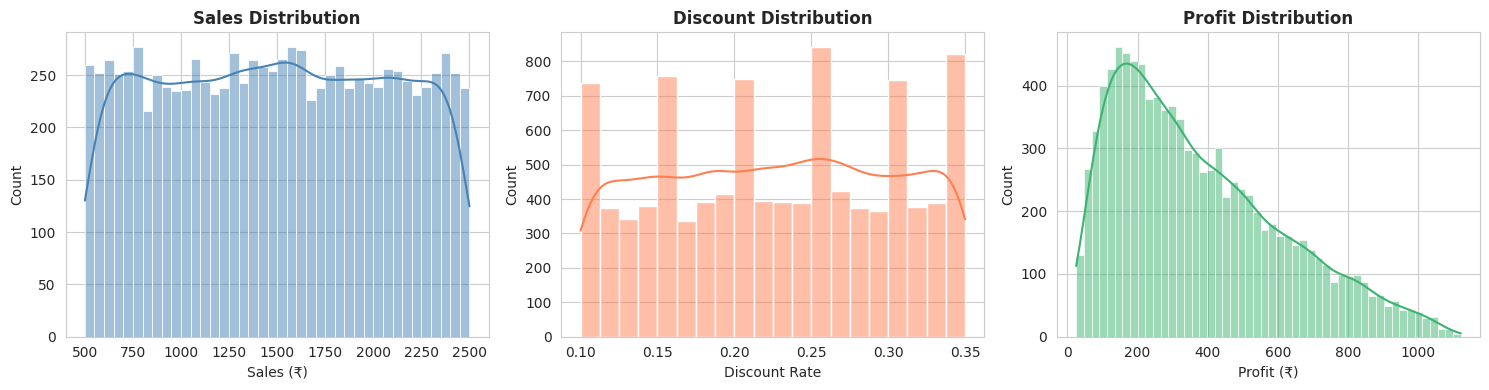


Distribution notes:
  Sales: ₹500 – ₹2,500 (uniform — equal spread across all price points)
  Discount: fixed slabs only — [np.float64(0.1), np.float64(0.11), np.float64(0.12), np.float64(0.13), np.float64(0.14), np.float64(0.15), np.float64(0.16), np.float64(0.17), np.float64(0.18), np.float64(0.19), np.float64(0.2), np.float64(0.21), np.float64(0.22), np.float64(0.23), np.float64(0.24), np.float64(0.25), np.float64(0.26), np.float64(0.27), np.float64(0.28), np.float64(0.29), np.float64(0.3), np.float64(0.31), np.float64(0.32), np.float64(0.33), np.float64(0.34), np.float64(0.35)]
  Profit: right-skewed, most orders between ₹180–₹526


In [ ]:
# ============================================================================
# SECTION 3 — UNDERSTAND THE DATA STRUCTURE
# ============================================================================

print("\n" + "=" * 70)
print("DATA OVERVIEW")
print("=" * 70)

print(f"\nSummary statistics:")
print(data[['Sales', 'Discount', 'Profit', 'Profit_Margin']].describe().round(3))

print(f"\nCategories ({data['Category'].nunique()}): {data['Category'].unique()}")
print(f"Sub-categories: {data['Sub Category'].nunique()}")
print(f"Cities: {data['City'].nunique()}")
print(f"Regions: {data['Region'].unique()}")
print(f"Unique customers: {data['Customer Name'].nunique()}")
print(f"Orders per customer (avg): {data.shape[0]/data['Customer Name'].nunique():.0f}")


# ============================================================================
# SECTION 4 — EDA: DISTRIBUTIONS
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(data['Sales'],   bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Sales Distribution',   fontweight='bold')
axes[0].set_xlabel('Sales (₹)')

sns.histplot(data['Discount'], bins=20, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Discount Distribution', fontweight='bold')
axes[1].set_xlabel('Discount Rate')

sns.histplot(data['Profit'],   bins=50, kde=True, ax=axes[2], color='mediumseagreen')
axes[2].set_title('Profit Distribution',   fontweight='bold')
axes[2].set_xlabel('Profit (₹)')

plt.tight_layout()
plt.savefig('images/01_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Key observations from distributions
sales_min, sales_max = data['Sales'].min(), data['Sales'].max()
disc_vals = sorted(data['Discount'].round(2).unique())

print(f"\nDistribution notes:")
print(f"  Sales: ₹{sales_min:,.0f} – ₹{sales_max:,.0f} (uniform — equal spread across all price points)")
print(f"  Discount: fixed slabs only — {disc_vals}")
print(f"  Profit: right-skewed, most orders between ₹{data['Profit'].quantile(0.25):,.0f}–₹{data['Profit'].quantile(0.75):,.0f}")



Category performance:
         Category  Total_Sales  Total_Profit  Avg_Margin  Revenue_Share
Eggs, Meat & Fish      2267401     567357.22    0.249020      15.160753
           Snacks      2237546     568178.85    0.253494      14.961131
      Food Grains      2115272     529162.64    0.249914      14.143558
           Bakery      2112281     528521.06    0.250941      14.123559
 Fruits & Veggies      2100727     530400.38    0.252412      14.046304
        Beverages      2085313     525605.76    0.251429      13.943240
     Oil & Masala      2037188     497494.01    0.243934      13.621457


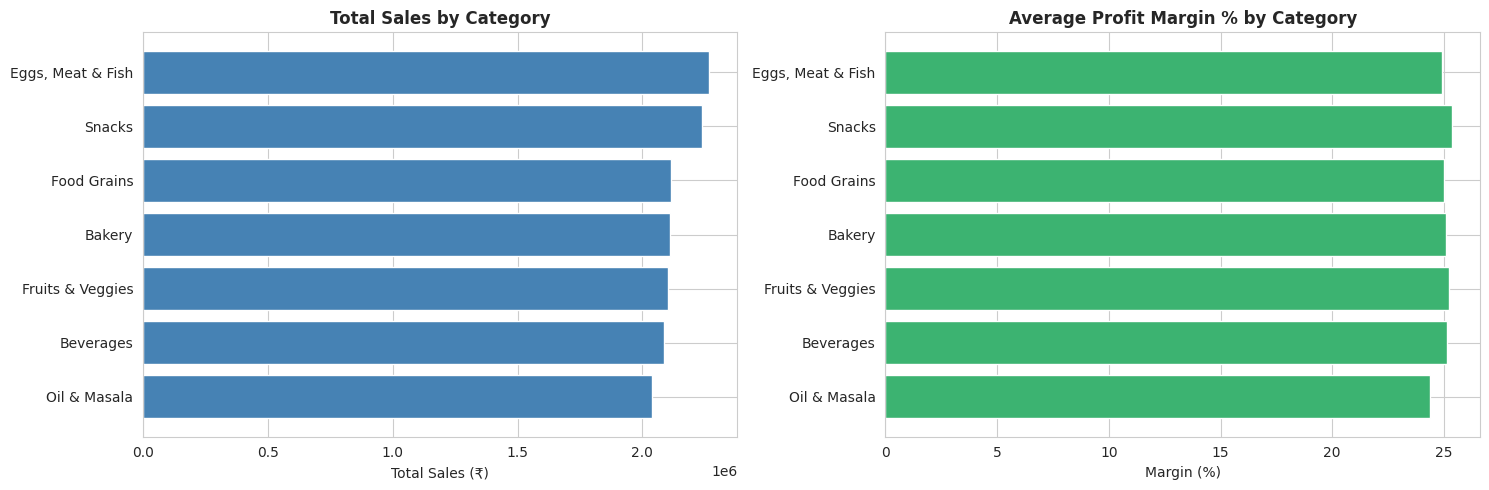

In [ ]:
# ============================================================================
# SECTION 5 — EDA: CATEGORY PERFORMANCE
# ============================================================================

cat_perf = data.groupby('Category').agg(
    Total_Sales   = ('Sales',  'sum'),
    Total_Profit  = ('Profit', 'sum'),
    Avg_Margin    = ('Profit_Margin', 'mean'),
    Order_Count   = ('Order ID', 'count')
).sort_values('Total_Sales', ascending=False).reset_index()

cat_perf['Revenue_Share'] = cat_perf['Total_Sales'] / cat_perf['Total_Sales'].sum() * 100

print("\nCategory performance:")
print(cat_perf[['Category', 'Total_Sales', 'Total_Profit',
                'Avg_Margin', 'Revenue_Share']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(cat_perf['Category'], cat_perf['Total_Sales'], color='steelblue')
axes[0].set_title('Total Sales by Category', fontweight='bold')
axes[0].set_xlabel('Total Sales (₹)')
axes[0].invert_yaxis()

axes[1].barh(cat_perf['Category'], cat_perf['Avg_Margin'] * 100, color='mediumseagreen')
axes[1].set_title('Average Profit Margin % by Category', fontweight='bold')
axes[1].set_xlabel('Margin (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('images/02_category_performance.png', dpi=300, bbox_inches='tight')
plt.show()



KEY FINDING: DISCOUNT-PROFIT RELATIONSHIP

Correlation matrix:
               Sales  Discount  Profit  Profit_Margin
Sales          1.000    -0.006   0.605          0.007
Discount      -0.006     1.000   0.000          0.008
Profit         0.605     0.000   1.000          0.747
Profit_Margin  0.007     0.008   0.747          1.000

Sales  ↔ Profit  : 0.605
Discount ↔ Profit  : 0.000
Discount ↔ Margin  : 0.008
Profit margin mean : 0.250
Profit margin std  : 0.119


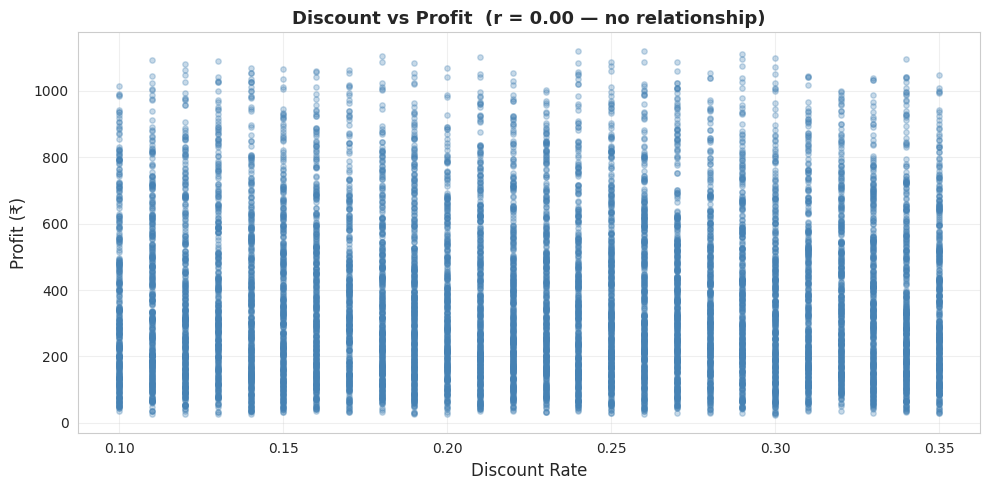


What this means:
  Profit = ~25% of Sales, regardless of Discount.
  Discounts are absorbed by cost adjustments, not margin compression.
  This is a fixed-markup model — unusual in real grocery retail where
  heavy discounts typically erode margin.



In [ ]:
# ============================================================================
# SECTION 6 — KEY FINDING: DISCOUNT VS PROFIT RELATIONSHIP
#
# This is the most analytically interesting finding in this dataset.
# Discount has ZERO correlation with profit (r=0.00) — meaning the company's
# profit is completely unaffected by the discount given.
# This reveals a fixed-markup pricing model: whatever the sales value is,
# profit is always ~25% of it regardless of discount.
# ============================================================================

print("\n" + "=" * 70)
print("KEY FINDING: DISCOUNT-PROFIT RELATIONSHIP")
print("=" * 70)

corr_matrix = data[['Sales', 'Discount', 'Profit', 'Profit_Margin']].corr()
print(f"\nCorrelation matrix:")
print(corr_matrix.round(3))

print(f"\nSales  ↔ Profit  : {corr_matrix.loc['Sales','Profit']:.3f}")
print(f"Discount ↔ Profit  : {corr_matrix.loc['Discount','Profit']:.3f}")
print(f"Discount ↔ Margin  : {corr_matrix.loc['Discount','Profit_Margin']:.3f}")
print(f"Profit margin mean : {data['Profit_Margin'].mean():.3f}")
print(f"Profit margin std  : {data['Profit_Margin'].std():.3f}")

# Scatter: Discount vs Profit — visualise the zero correlation
plt.figure(figsize=(10, 5))
plt.scatter(data['Discount'], data['Profit'], alpha=0.3, s=15, color='steelblue')
plt.xlabel('Discount Rate', fontsize=12)
plt.ylabel('Profit (₹)', fontsize=12)
plt.title('Discount vs Profit  (r = 0.00 — no relationship)',
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/03_discount_profit.png', dpi=300, bbox_inches='tight')
plt.show()

print("""
What this means:
  Profit = ~25% of Sales, regardless of Discount.
  Discounts are absorbed by cost adjustments, not margin compression.
  This is a fixed-markup model — unusual in real grocery retail where
  heavy discounts typically erode margin.
""")



Regional performance:
 Region  Total_Sales  Total_Profit  Orders  Sales_Share
   West      4798743    1192004.61    3203    32.086322
   East      4248368    1074345.58    2848    28.406294
Central      3468156     856806.84    2323    23.189483
  South      2440461     623562.89    1619    16.317902


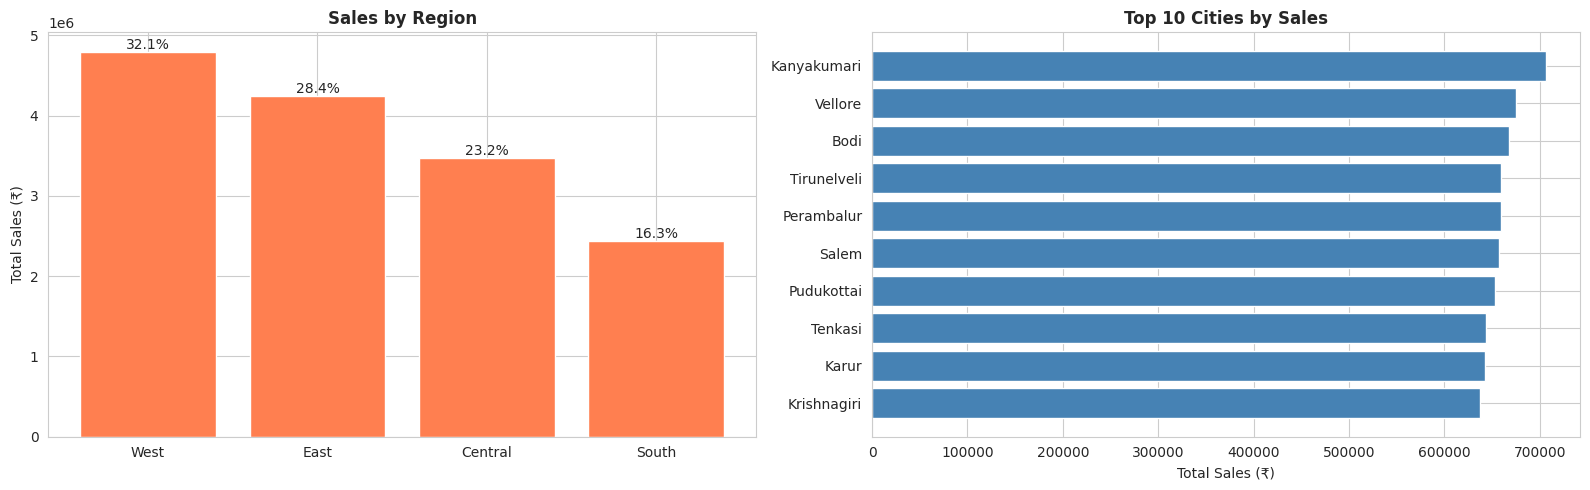


Top region: West at 32.1% of revenue
Top city  : Kanyakumari — ₹706,764
Top 10 cities: 44.1% of total revenue


In [ ]:
# ============================================================================
# SECTION 7 — REGIONAL AND GEOGRAPHIC ANALYSIS
# ============================================================================

region_perf = data.groupby('Region').agg(
    Total_Sales  = ('Sales',     'sum'),
    Total_Profit = ('Profit',    'sum'),
    Orders       = ('Order ID',  'count')
).sort_values('Total_Sales', ascending=False).reset_index()

region_perf['Sales_Share'] = region_perf['Total_Sales'] / region_perf['Total_Sales'].sum() * 100

print("\nRegional performance:")
print(region_perf.to_string(index=False))

# Top 10 cities
city_perf = data.groupby('City').agg(
    Total_Sales = ('Sales',    'sum'),
    Orders      = ('Order ID', 'count'),
    Customers   = ('Customer Name', 'nunique')
).sort_values('Total_Sales', ascending=False).head(10).reset_index()

city_perf['Avg_Order'] = city_perf['Total_Sales'] / city_perf['Orders']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(region_perf['Region'], region_perf['Total_Sales'], color='coral')
axes[0].set_title('Sales by Region', fontweight='bold')
axes[0].set_ylabel('Total Sales (₹)')
for i, (_, row) in enumerate(region_perf.iterrows()):
    axes[0].text(i, row['Total_Sales'],
                 f"{row['Sales_Share']:.1f}%", ha='center', va='bottom', fontsize=10)

axes[1].barh(city_perf['City'], city_perf['Total_Sales'], color='steelblue')
axes[1].set_title('Top 10 Cities by Sales', fontweight='bold')
axes[1].set_xlabel('Total Sales (₹)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('images/04_regional_city.png', dpi=300, bbox_inches='tight')
plt.show()

top10_share = city_perf['Total_Sales'].sum() / data['Sales'].sum() * 100
print(f"\nTop region: {region_perf.iloc[0]['Region']} at {region_perf.iloc[0]['Sales_Share']:.1f}% of revenue")
print(f"Top city  : {city_perf.iloc[0]['City']} — ₹{city_perf.iloc[0]['Total_Sales']:,.0f}")
print(f"Top 10 cities: {top10_share:.1f}% of total revenue")


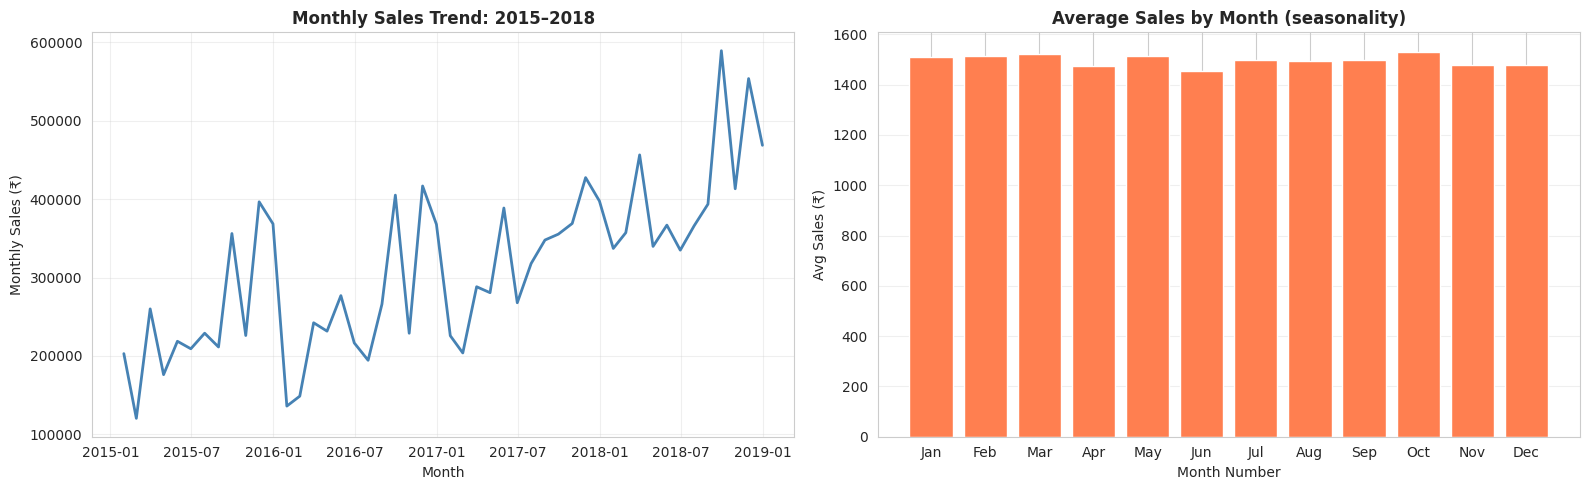


Temporal summary:
  Start (Jan 2015) : ₹203,014/month
  End  (Dec 2018)  : ₹468,719/month
  Growth           : +131% over 4 years
  Linear trend     : ₹5,462/month average increase
  Peak month       : Month 10 (avg ₹1,531)
  Trough month     : Month 6 (avg ₹1,455)


In [ ]:
# ============================================================================
# SECTION 8 — TEMPORAL ANALYSIS: SALES TREND 2015–2018
# ============================================================================

monthly = (data.set_index('Order Date')
               .resample('M')['Sales']
               .sum()
               .reset_index())
monthly.columns = ['Date', 'Sales']
monthly['Month_Num'] = range(len(monthly))

# Monthly by year — to spot seasonality
monthly_avg = data.groupby('Month')['Sales'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(monthly['Date'], monthly['Sales'], lw=2, color='steelblue')
axes[0].set_title('Monthly Sales Trend: 2015–2018', fontweight='bold')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Monthly Sales (₹)')
axes[0].grid(True, alpha=0.3)

axes[1].bar(monthly_avg.index, monthly_avg.values, color='coral')
axes[1].set_title('Average Sales by Month (seasonality)', fontweight='bold')
axes[1].set_xlabel('Month Number'); axes[1].set_ylabel('Avg Sales (₹)')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('images/05_temporal.png', dpi=300, bbox_inches='tight')
plt.show()

# Simple linear forecast
lr = LinearRegression()
lr.fit(monthly[['Month_Num']], monthly['Sales'])
growth_per_month = lr.coef_[0]
start_sales = monthly['Sales'].iloc[0]
end_sales   = monthly['Sales'].iloc[-1]
total_growth_pct = (end_sales - start_sales) / start_sales * 100

peak_month   = monthly_avg.idxmax()
trough_month = monthly_avg.idxmin()

print(f"\nTemporal summary:")
print(f"  Start (Jan 2015) : ₹{start_sales:,.0f}/month")
print(f"  End  (Dec 2018)  : ₹{end_sales:,.0f}/month")
print(f"  Growth           : +{total_growth_pct:.0f}% over 4 years")
print(f"  Linear trend     : ₹{growth_per_month:,.0f}/month average increase")
print(f"  Peak month       : Month {peak_month} (avg ₹{monthly_avg[peak_month]:,.0f})")
print(f"  Trough month     : Month {trough_month} (avg ₹{monthly_avg[trough_month]:,.0f})")


RFM CUSTOMER SEGMENTATION

Unique customers   : 50
Total orders       : 9,993
Avg orders/customer: 200
Note: ~200 orders/customer is a synthetic pattern — interpret as B2B accounts.

RFM segment summary:
            Segment  Customers  Total_Rev       Avg_Rev  Avg_Recency   Avg_Freq  Rev_Share
          Champions          8    2575253 321906.625000     2.750000 215.500000  17.219175
              Loyal          9    2782476 309164.000000     3.444444 205.666667  18.604751
Potential Loyalists         11    3322670 302060.909091     3.636364 199.090909  22.216705
            At Risk         11    3213208 292109.818182     5.000000 195.818182  21.484798
               Lost         11    3062121 278374.636364     8.909091 188.545455  20.474570


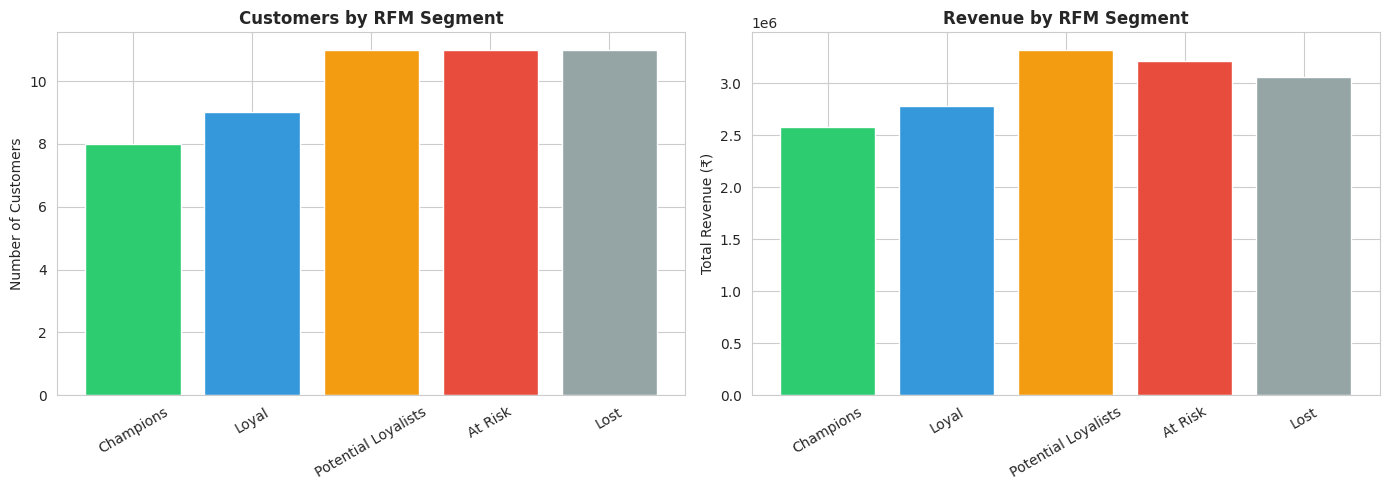

In [ ]:
# ============================================================================
# SECTION 9 — RFM CUSTOMER SEGMENTATION
#
# NOTE: This dataset has only 50 unique customers across 9,993 orders.
# That is ~200 orders per customer — far more than typical B2C retail.
# This is a synthetic data artifact. The RFM analysis is methodologically
# correct but results should be interpreted as a B2B-style account analysis,
# not individual consumer behaviour.
# ============================================================================

print("\n" + "=" * 70)
print("RFM CUSTOMER SEGMENTATION")
print("=" * 70)

unique_customers = data['Customer Name'].nunique()
orders_per_customer = data.shape[0] / unique_customers
print(f"\nUnique customers   : {unique_customers}")
print(f"Total orders       : {data.shape[0]:,}")
print(f"Avg orders/customer: {orders_per_customer:.0f}")
print("Note: ~200 orders/customer is a synthetic pattern — interpret as B2B accounts.")

ref_date = data['Order Date'].max() + pd.Timedelta(days=1)

rfm = data.groupby('Customer Name').agg(
    Recency   = ('Order Date', lambda x: (ref_date - x.max()).days),
    Frequency = ('Order ID',   'count'),
    Monetary  = ('Sales',      'sum')
).reset_index()

rfm['R'] = pd.qcut(rfm['Recency'],   5, labels=[5,4,3,2,1], duplicates='drop').astype(int)
rfm['F'] = pd.qcut(rfm['Frequency'], 5, labels=[1,2,3,4,5], duplicates='drop').astype(int)
rfm['M'] = pd.qcut(rfm['Monetary'],  5, labels=[1,2,3,4,5], duplicates='drop').astype(int)
rfm['RFM_Score'] = rfm['R'] + rfm['F'] + rfm['M']

def segment(row):
    if row['RFM_Score'] >= 13: return 'Champions'
    if row['RFM_Score'] >= 11: return 'Loyal'
    if row['RFM_Score'] >= 9:  return 'Potential Loyalists'
    if row['RFM_Score'] >= 7:  return 'At Risk'
    return 'Lost'

rfm['Segment'] = rfm.apply(segment, axis=1)

seg_summary = rfm.groupby('Segment').agg(
    Customers   = ('Customer Name', 'count'),
    Total_Rev   = ('Monetary', 'sum'),
    Avg_Rev     = ('Monetary', 'mean'),
    Avg_Recency = ('Recency',  'mean'),
    Avg_Freq    = ('Frequency','mean')
).reset_index()

seg_summary['Rev_Share'] = seg_summary['Total_Rev'] / seg_summary['Total_Rev'].sum() * 100
seg_order = ['Champions', 'Loyal', 'Potential Loyalists', 'At Risk', 'Lost']
seg_summary['order'] = seg_summary['Segment'].map({s:i for i,s in enumerate(seg_order)})
seg_summary = seg_summary.sort_values('order').drop('order', axis=1)

print("\nRFM segment summary:")
print(seg_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ECC71','#3498DB','#F39C12','#E74C3C','#95A5A6']
axes[0].bar(seg_summary['Segment'], seg_summary['Customers'], color=colors)
axes[0].set_title('Customers by RFM Segment', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(seg_summary['Segment'], seg_summary['Total_Rev'], color=colors)
axes[1].set_title('Revenue by RFM Segment', fontweight='bold')
axes[1].set_ylabel('Total Revenue (₹)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('images/06_rfm_segments.png', dpi=300, bbox_inches='tight')
plt.show()

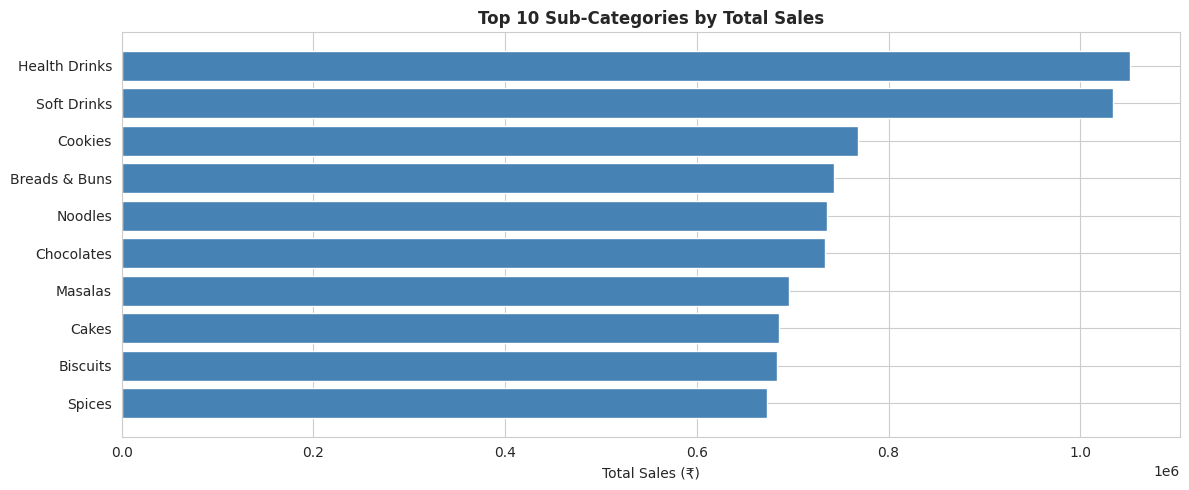


Top 10 sub-categories:
 Sub Category   Sales    Profit    Margin  Orders
Health Drinks 1051439 267469.79 25.438451     719
  Soft Drinks 1033874 258135.97 24.967837     681
      Cookies  768213 190643.70 24.816516     520
Breads & Buns  742586 190764.98 25.689278     502
      Noodles  735435 193685.81 26.336224     495
   Chocolates  733898 183849.34 25.051075     499
      Masalas  696226 168597.83 24.215963     462
        Cakes  685612 168398.46 24.561773     452
     Biscuits  684083 169357.62 24.756882     459
       Spices  672876 160302.60 23.823498     447


In [ ]:
# ============================================================================
# SECTION 10 — SUB-CATEGORY DEEP DIVE
# ============================================================================

subcat = data.groupby('Sub Category').agg(
    Sales  = ('Sales',  'sum'),
    Profit = ('Profit', 'sum'),
    Orders = ('Order ID','count')
).sort_values('Sales', ascending=False).head(10).reset_index()

subcat['Margin'] = subcat['Profit'] / subcat['Sales'] * 100

plt.figure(figsize=(12, 5))
plt.barh(subcat['Sub Category'], subcat['Sales'], color='steelblue')
plt.title('Top 10 Sub-Categories by Total Sales', fontweight='bold')
plt.xlabel('Total Sales (₹)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('images/07_subcategory.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 sub-categories:")
print(subcat[['Sub Category','Sales','Profit','Margin','Orders']].to_string(index=False))

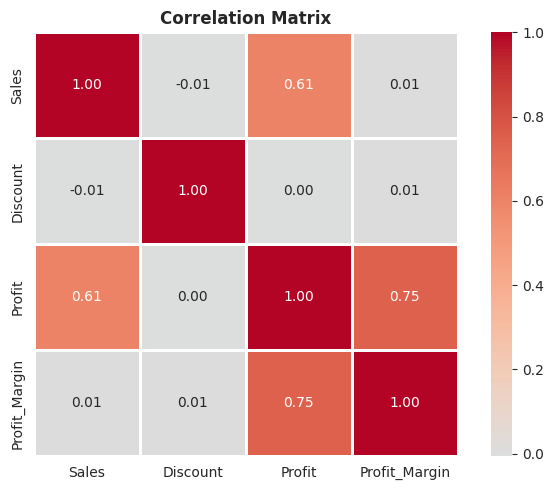

In [ ]:
# ============================================================================
# SECTION 11 — CORRELATION HEATMAP
# ============================================================================

plt.figure(figsize=(7, 5))
sns.heatmap(
    data[['Sales','Discount','Profit','Profit_Margin']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, linewidths=1
)
plt.title('Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('images/08_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================================
# SECTION 12 — KEY FINDINGS SUMMARY
# ============================================================================

total_sales  = data['Sales'].sum()
total_profit = data['Profit'].sum()
champ_count  = (rfm['Segment'] == 'Champions').sum()
champ_rev    = rfm[rfm['Segment'] == 'Champions']['Monetary'].sum()
lost_count   = (rfm['Segment'] == 'Lost').sum()
lost_rev     = rfm[rfm['Segment'] == 'Lost']['Monetary'].sum()

print("\n" + "=" * 70)
print("KEY FINDINGS")
print("=" * 70)

print(f"""
1. REVENUE GROWTH (131% over 4 years)
   Jan 2015: ₹{start_sales:,.0f}/month  →  Dec 2018: ₹{end_sales:,.0f}/month
   Linear trend: +₹{growth_per_month:,.0f} per month
   Total 4-year revenue: ₹{total_sales:,.0f}

2. DISCOUNT HAS ZERO EFFECT ON PROFIT (r = 0.00)
   Profit margin mean: {data['Profit_Margin'].mean():.1%}   Std: {data['Profit_Margin'].std():.1%}
   Discount correlates with neither profit nor margin.
   The company uses fixed-markup pricing — profit = ~25% of Sales always.

3. WEST REGION DOMINATES — 32.1% of total revenue
   Regional breakdown:
   {region_perf[['Region','Total_Sales','Sales_Share']].to_string(index=False)}

4. TOP 10 CITIES DRIVE {top10_share:.1f}% OF REVENUE
   #1: {city_perf.iloc[0]['City']} (₹{city_perf.iloc[0]['Total_Sales']:,.0f})
   High geographic concentration means growth needs new city penetration.

5. 50 CUSTOMERS, ~200 ORDERS EACH (synthetic artifact)
   Champions : {champ_count} customers → ₹{champ_rev:,.0f} revenue
   At Risk   : {(rfm['Segment']=='At Risk').sum()} customers → ₹{rfm[rfm['Segment']=='At Risk']['Monetary'].sum():,.0f} revenue
   Lost      : {lost_count} customers → ₹{lost_rev:,.0f} revenue (re-engagement opportunity)

6. HEALTH DRINKS LEADS SUB-CATEGORIES
   ₹{subcat.iloc[0]['Sales']:,.0f} total — {subcat.iloc[0]['Sales']/total_sales*100:.1f}% of all revenue
   Beverages (Health Drinks + Soft Drinks) are the volume leaders.

7. ALL MARGINS ARE 24–25% (synthetic data artifact)
   In real grocery, margins vary 5–40% by category.
   This confirms a fixed-markup formula in the dataset.
   Stated as an observation, not a business recommendation.
""")

print("=" * 70)
print("ANALYSIS COMPLETE — 8 charts saved to /images/")
print("=" * 70)




KEY FINDINGS

1. REVENUE GROWTH (131% over 4 years)
   Jan 2015: ₹203,014/month  →  Dec 2018: ₹468,719/month
   Linear trend: +₹5,462 per month
   Total 4-year revenue: ₹14,955,728
 
2. DISCOUNT HAS ZERO EFFECT ON PROFIT (r = 0.00)
   Profit margin mean: 25.0%   Std: 11.9%
   Discount correlates with neither profit nor margin.
   The company uses fixed-markup pricing — profit = ~25% of Sales always.
 
3. WEST REGION DOMINATES — 32.1% of total revenue
   Regional breakdown:
    Region  Total_Sales  Sales_Share
   West      4798743    32.086322
   East      4248368    28.406294
Central      3468156    23.189483
  South      2440461    16.317902
 
4. TOP 10 CITIES DRIVE 44.1% OF REVENUE
   #1: Kanyakumari (₹706,764)
   High geographic concentration means growth needs new city penetration.
 
5. 50 CUSTOMERS, ~200 ORDERS EACH (synthetic artifact)
   Champions : 8 customers → ₹2,575,253 revenue
   At Risk   : 11 customers → ₹3,213,208 revenue
   Lost      : 11 customers → ₹3,062,121 revenue